# Aerogel Filtration ML --> Step 4: Nested Cross-Validation

**What this notebook does:**
- Runs nested cross-validation for Random Forest, XGBoost, and LASSO/ElasticNet
- Tunes hyperparameters inside each fold (to avoid data leakage)
- Uses RepeatedStratifiedKFold (5 splits × 10 repeats = 50 folds) for the outer loop
- Targets: log_penetration for filtration efficiency and log_quality_factor for QF

## 4.1: Install and import libraries

In [1]:
!pip install scikit-learn xgboost pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import (
    KFold, StratifiedKFold, RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ---------------- Core CV settings -------------------------
# N_OUTER_SPLITS × N_REPEATS = total number of test folds scored
# 5 splits × 10 repeats = 50 folds per model/target combination.

RANDOM_STATE    = 42
N_OUTER_SPLITS  = 5
N_REPEATS       = 10
N_INNER_SPLITS  = 5   # inner CV splits — hyperparameter tuning
N_STRAT_BINS    = 4   # quartile bins for stratification

print('All libraries loaded.')
print(f'Outer CV: {N_OUTER_SPLITS} splits × {N_REPEATS} repeats = '
      f'{N_OUTER_SPLITS * N_REPEATS} total folds per model')


All libraries loaded.
Outer CV: 5 splits × 10 repeats = 50 total folds per model


## 4.2: Load data and define features

In [2]:
df_eff = pd.read_csv('model_data_filtration.csv')
df_qf  = pd.read_csv('model_data_qualityfactor.csv')

# Columns that are targets or identifiers — not features
NON_FEATURE_COLS = [
    'sample_id',
    'filtration_efficiency (%)',
    'log_penetration',
    'quality_factor (mmH2O^-1)',
    'log_quality_factor',
    'pressure_drop (mmH2O/cm)',
]

def get_features(df):
    return [c for c in df.columns if c not in NON_FEATURE_COLS]

FEATURES_EFF = get_features(df_eff)
FEATURES_QF  = get_features(df_qf)

# --------------- Target arrays -----------------------
# Both targets are used on the log-transformed scale for training
# AND evaluation.
#   Filtration efficiency → log_penetration = log(100 - η)
#   Quality factor        → log_quality_factor = log(QF + 1)

X_eff = df_eff[FEATURES_EFF].copy()
y_eff = df_eff['log_penetration'].copy()

X_qf  = df_qf[FEATURES_QF].copy()
y_qf  = df_qf['log_quality_factor'].copy()

# ----------------- Sanity check: all commercial benchmarks still present -----------

commercial_eff = df_eff[df_eff['sample_id'].str.contains('ommercial|urgical|N-95|HEPA',
                                                           case=False, na=False, regex=True)]
commercial_qf  = df_qf[df_qf['sample_id'].str.contains('ommercial|urgical|N-95|HEPA',
                                                        case=False, na=False, regex=True)]

print(f'Filtration efficiency: X={X_eff.shape}, y={y_eff.shape}')
print(f'Quality factor:        X={X_qf.shape},  y={y_qf.shape}')
print()
print(f'Commercial benchmarks in efficiency dataset: {len(commercial_eff)}')
print(commercial_eff['sample_id'].tolist())
print()
print(f'Commercial benchmarks in QF dataset: {len(commercial_qf)}')
print(commercial_qf['sample_id'].tolist())


Filtration efficiency: X=(195, 57), y=(195,)
Quality factor:        X=(82, 57),  y=(82,)

Commercial benchmarks in efficiency dataset: 27
['HEPA-BASE-125', 'HEPA-BASE-175', 'HEPA-BASE-250', 'HEPA-W-0.005-125', 'HEPA-W-0.005-175', 'HEPA-W-0.005-250', 'HEPA-W-0.015-125', 'HEPA-W-0.015-175', 'HEPA-W-0.015-250', 'HEPA-W-0.030-125', 'HEPA-W-0.030-175', 'HEPA-W-0.030-250', 'HEPA-TBA30-0.005-125', 'HEPA-TBA30-0.005-175', 'HEPA-TBA30-0.005-250', 'HEPA-TBA30-0.015-125', 'HEPA-TBA30-0.015-175', 'HEPA-TBA30-0.015-250', 'HEPA-TBA30-0.031-125', 'HEPA-TBA30-0.031-175', 'HEPA-TBA30-0.031-250', 'surgical mask', 'N-95', 'Commercial-1', 'Commercial-2', 'Commercial 12', 'Commercial 22']

Commercial benchmarks in QF dataset: 1
['surgical mask']


## 4.3: Define CV splitters

For the outer loop we use RepeatedStratifiedKFold for both targets. Stratification bins are
built from quartiles of the (log-transformed) target itself — this ensures that extreme values
are spread across every fold rather than concentrated in one, and the repeats average away
the seed-specific accident of any one split.

The inner loop (hyperparameter tuning) uses plain KFold — a stratified inner loop is not
required because the inner loop only ranks candidate hyperparameter sets.


In [3]:
# Build quartile bins from the TARGETS, used only for stratification.
# pd.qcut with labels=False returns integer bin indices (0..3).

eff_bins = pd.qcut(y_eff, q=N_STRAT_BINS, labels=False, duplicates='drop')
qf_bins  = pd.qcut(y_qf,  q=N_STRAT_BINS, labels=False, duplicates='drop')

# outer CV: RepeatedStratifiedKFold for both targets
outer_cv_eff = RepeatedStratifiedKFold(
    n_splits=N_OUTER_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)
outer_cv_qf = RepeatedStratifiedKFold(
    n_splits=N_OUTER_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

# Precompute split lists so every model family evaluates on the same folds
outer_splits_eff = list(outer_cv_eff.split(X_eff, eff_bins))
outer_splits_qf  = list(outer_cv_qf.split(X_qf, qf_bins))

# Inner CV — plain KFold is sufficient for hyperparameter ranking
inner_cv = KFold(n_splits=N_INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ----------------- Fold balance check ----------------------
# Report min/max test-fold variance; if the ratio is very large the
# stratification is failing to prevent variance collapse.

def fold_variance_report(splits, y, label):
    variances = [np.var(y.iloc[te]) for _, te in splits]
    print(f'{label}:')
    print(f'  median test-fold variance = {np.median(variances):.4f}')
    print(f'  min    test-fold variance = {np.min(variances):.4f}')
    print(f'  max    test-fold variance = {np.max(variances):.4f}')
    print(f'  ratio max/min             = {np.max(variances)/max(np.min(variances),1e-9):.2f}')

fold_variance_report(outer_splits_eff, y_eff, 'Filtration efficiency (log_penetration)')
print()
fold_variance_report(outer_splits_qf,  y_qf,  'Quality factor (log_quality_factor)')
print()
print(f'Total outer folds: {len(outer_splits_eff)} for each target')


Filtration efficiency (log_penetration):
  median test-fold variance = 10.6222
  min    test-fold variance = 7.9745
  max    test-fold variance = 12.5517
  ratio max/min             = 1.57

Quality factor (log_quality_factor):
  median test-fold variance = 0.8913
  min    test-fold variance = 0.0736
  max    test-fold variance = 2.5677
  ratio max/min             = 34.90

Total outer folds: 50 for each target


## 4.4: Helper: nested CV engine

`nested_cv()` runs the outer–inner loop for a single model family:

- For each outer fold: fit KNN imputer on the training partition only
- If `needs_scaling=True`: fit RobustScaler inside the fold (for LASSO/ElasticNet)
- Run the inner GridSearchCV to pick hyperparameters on the training partition
- Score the best inner model on the outer test fold

Progress is printed once per 10 folds (instead of every fold) because 50 folds per
model family would otherwise produce 150 log lines.


In [4]:
def bootstrap_ci(scores, n_boot=1000, ci=95, random_state=42):
    """
    Bootstrap confidence interval for the mean of a list of scores.
    Returns (lower, upper) percentiles of the bootstrap distribution of the mean.
    """
    rng = np.random.RandomState(random_state)
    boot_means = [
        np.mean(rng.choice(scores, size=len(scores), replace=True))
        for _ in range(n_boot)
    ]
    alpha = (100 - ci) / 2
    return np.percentile(boot_means, alpha), np.percentile(boot_means, 100 - alpha)


def nested_cv(
    model_class, param_grid, X, y,
    outer_splits,
    inner_cv,
    needs_scaling=False,
    model_name='Model',
    print_every=10,
):
    """
    Run nested cross-validation.

    Parameters
    ----------
    model_class    : estimator class (must be callable to instantiate)
    param_grid     : dict passed to GridSearchCV
    X, y           : pandas DataFrame / Series of features and target
    outer_splits   : list of (train_idx, test_idx) for the outer loop
    inner_cv       : CV splitter used inside GridSearchCV
    needs_scaling  : if True, apply RobustScaler inside each fold
    model_name     : label used in print statements
    print_every    : print progress every N folds

    Returns
    -------
    dict with per-fold r2/rmse/mae, summary statistics, and best params per fold.
    """
    fold_r2, fold_rmse, fold_mae = [], [], []
    best_params_list = []

    print(f'Running nested CV for {model_name} '
          f'({len(outer_splits)} outer folds)...')

    for fold_num, (train_idx, test_idx) in enumerate(outer_splits, start=1):
        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test  = y.iloc[test_idx].copy()

        # Step 1: KNN imputation fitted on training partition only
        imputer = KNNImputer(n_neighbors=5)
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp  = imputer.transform(X_test)

        # Step 2: Scaling inside the fold (LASSO/ElasticNet only)
        if needs_scaling:
            scaler = RobustScaler()
            X_train_imp = scaler.fit_transform(X_train_imp)
            X_test_imp  = scaler.transform(X_test_imp)

        # Step 3: Inner GridSearchCV
        # n_jobs: -1 on GridSearchCV, 1 on the model itself (avoids oversubscription)
        
        grid = GridSearchCV(
            model_class(),
            param_grid,
            cv=inner_cv,
            scoring='r2',
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train_imp, y_train)
        best_params_list.append(grid.best_params_)

        # Step 4: Evaluate on the outer test fold (log scale, consistent with target)
        
        y_pred = grid.predict(X_test_imp)
        fold_r2.append(r2_score(y_test, y_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        fold_mae.append(mean_absolute_error(y_test, y_pred))

        if fold_num % print_every == 0 or fold_num == len(outer_splits):
            print(f'  Fold {fold_num:>3}/{len(outer_splits)}: '
                  f'R²={fold_r2[-1]:+.3f}  '
                  f'running median R²={np.median(fold_r2):+.3f}')

    # Summary statistics: both mean and median reported.
    # With 50 folds the median is a robust headline number that is not
    # dominated by a single unlucky fold.

    r2_ci = bootstrap_ci(fold_r2)
    results = {
        'model':       model_name,
        'fold_r2':     fold_r2,
        'fold_rmse':   fold_rmse,
        'fold_mae':    fold_mae,
        'mean_r2':     float(np.mean(fold_r2)),
        'std_r2':      float(np.std(fold_r2)),
        'median_r2':   float(np.median(fold_r2)),
        'iqr_r2':      (float(np.percentile(fold_r2, 25)),
                        float(np.percentile(fold_r2, 75))),
        'ci_r2':       r2_ci,
        'mean_rmse':   float(np.mean(fold_rmse)),
        'median_rmse': float(np.median(fold_rmse)),
        'mean_mae':    float(np.mean(fold_mae)),
        'median_mae':  float(np.median(fold_mae)),
        'best_params': best_params_list,
    }

    print(f'  → mean   R² = {results["mean_r2"]:+.4f} ± {results["std_r2"]:.4f}')
    print(f'  → median R² = {results["median_r2"]:+.4f}  '
          f'IQR [{results["iqr_r2"][0]:+.4f}, {results["iqr_r2"][1]:+.4f}]')
    print(f'  → 95% bootstrap CI on mean: '
          f'[{r2_ci[0]:+.4f}, {r2_ci[1]:+.4f}]')
    print()
    return results


print('Helper functions defined.')


Helper functions defined.


## 4.5: Define models and hyperparameter grids

In [5]:
# Hyperparameter grids kept identical to the original pipeline so that
# any change in reported R² is attributable to the CV revision, not to
# a different search space.

RF_GRID = {
    'n_estimators':    [300, 500],
    'max_features':    ['sqrt', 0.5],
    'min_samples_leaf':[1, 2, 4],
    'max_depth':       [None, 10, 20],
}

XGB_GRID = {
    'n_estimators':    [100, 300],
    'learning_rate':   [0.05, 0.1],
    'max_depth':       [3, 5, 7],
    'subsample':       [0.7, 1.0],
    'colsample_bytree':[0.7, 1.0],
}

LASSO_GRID = {
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0],   # 1.0 = pure LASSO
    'max_iter': [10000],
}

rf_combos    = np.prod([len(v) for v in RF_GRID.values()])
xgb_combos   = np.prod([len(v) for v in XGB_GRID.values()])
lasso_combos = len(LASSO_GRID['l1_ratio'])

print(f'RF grid combinations:    {rf_combos}')
print(f'XGB grid combinations:   {xgb_combos}')
print(f'LASSO l1_ratio values:   {lasso_combos}')


RF grid combinations:    36
XGB grid combinations:   48
LASSO l1_ratio values:   5


## 4.6: Run nested CV: Filtration efficiency

All three models are trained on `log_penetration` and evaluated on the log scale,
which is the statistically correct scale for a heavily skewed target (skewness ≈ −2.93
on the raw scale). The repeated stratified k-fold design prevents any single accidental
split from dominating the reported performance.


In [6]:
print('=' * 60)
print('TARGET: log_penetration  (filtration efficiency)')
print('=' * 60)
print(f'Samples: {len(X_eff)}, Features: {len(FEATURES_EFF)}')
print()

# ------------ Random Forest ---------------------------

results_rf_eff = nested_cv(
    RandomForestRegressor,
    {**RF_GRID, 'random_state': [RANDOM_STATE], 'n_jobs': [1]},
    X_eff, y_eff,
    outer_splits=outer_splits_eff,
    inner_cv=inner_cv,
    needs_scaling=False,
    model_name='Random Forest'
)


TARGET: log_penetration  (filtration efficiency)
Samples: 195, Features: 57

Running nested CV for Random Forest (50 outer folds)...
  Fold  10/50: R²=+0.668  running median R²=+0.672
  Fold  20/50: R²=+0.687  running median R²=+0.666
  Fold  30/50: R²=+0.650  running median R²=+0.659
  Fold  40/50: R²=+0.708  running median R²=+0.659
  Fold  50/50: R²=+0.649  running median R²=+0.650
  → mean   R² = +0.6602 ± 0.0779
  → median R² = +0.6499  IQR [+0.6162, +0.7073]
  → 95% bootstrap CI on mean: [+0.6380, +0.6809]



In [7]:
# ------------------ XGBoost --------------------------------------

def XGBRegressorWrapper():
    return XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method='hist',
        verbosity=0,
    )

results_xgb_eff = nested_cv(
    XGBRegressorWrapper,
    XGB_GRID,
    X_eff, y_eff,
    outer_splits=outer_splits_eff,
    inner_cv=inner_cv,
    needs_scaling=False,
    model_name='XGBoost'
)


Running nested CV for XGBoost (50 outer folds)...
  Fold  10/50: R²=+0.703  running median R²=+0.672
  Fold  20/50: R²=+0.653  running median R²=+0.672
  Fold  30/50: R²=+0.605  running median R²=+0.652
  Fold  40/50: R²=+0.714  running median R²=+0.650
  Fold  50/50: R²=+0.581  running median R²=+0.632
  → mean   R² = +0.6370 ± 0.0985
  → median R² = +0.6319  IQR [+0.5831, +0.7038]
  → 95% bootstrap CI on mean: [+0.6091, +0.6641]



In [8]:
# ------------------ LASSO / ElasticNet ------------------------
# needs_scaling=True: RobustScaler is applied inside each fold.
# ElasticNet generalises LASSO: l1_ratio=1.0 is pure LASSO,
# l1_ratio<1.0 adds L2 regularisation.

def ElasticNetCVWrapper():
    return ElasticNetCV(random_state=RANDOM_STATE, cv=3)

results_lasso_eff = nested_cv(
    ElasticNetCVWrapper,
    LASSO_GRID,
    X_eff, y_eff,
    outer_splits=outer_splits_eff,
    inner_cv=inner_cv,
    needs_scaling=True,
    model_name='LASSO/ElasticNet'
)

print('All three models done for filtration efficiency.')


Running nested CV for LASSO/ElasticNet (50 outer folds)...
  Fold  10/50: R²=+0.531  running median R²=+0.381
  Fold  20/50: R²=+0.404  running median R²=+0.409
  Fold  30/50: R²=+0.436  running median R²=+0.411
  Fold  40/50: R²=-0.053  running median R²=+0.415
  Fold  50/50: R²=+0.490  running median R²=+0.410
  → mean   R² = -1.5876 ± 11.0143
  → median R² = +0.4098  IQR [+0.3203, +0.4675]
  → 95% bootstrap CI on mean: [-5.6819, +0.3926]

All three models done for filtration efficiency.


## 4.7: Run nested CV: Quality factor

Same three models, now on `log_quality_factor`.


In [9]:
print('=' * 60)
print('TARGET: log_quality_factor')
print('=' * 60)
print(f'Samples: {len(X_qf)}, Features: {len(FEATURES_QF)}')
print()

# ------------------- Random Forest ---------------------------
results_rf_qf = nested_cv(
    RandomForestRegressor,
    {**RF_GRID, 'random_state': [RANDOM_STATE], 'n_jobs': [1]},
    X_qf, y_qf,
    outer_splits=outer_splits_qf,
    inner_cv=inner_cv,
    needs_scaling=False,
    model_name='Random Forest'
)


TARGET: log_quality_factor
Samples: 82, Features: 57

Running nested CV for Random Forest (50 outer folds)...
  Fold  10/50: R²=+0.771  running median R²=+0.762
  Fold  20/50: R²=+0.552  running median R²=+0.753
  Fold  30/50: R²=+0.748  running median R²=+0.762
  Fold  40/50: R²=+0.676  running median R²=+0.762
  Fold  50/50: R²=+0.969  running median R²=+0.753
  → mean   R² = +0.6193 ± 0.3805
  → median R² = +0.7531  IQR [+0.5431, +0.8292]
  → 95% bootstrap CI on mean: [+0.5081, +0.7069]



In [10]:
# ---------------- XGBoost ---------------------------------

results_xgb_qf = nested_cv(
    XGBRegressorWrapper,
    XGB_GRID,
    X_qf, y_qf,
    outer_splits=outer_splits_qf,
    inner_cv=inner_cv,
    needs_scaling=False,
    model_name='XGBoost'
)


Running nested CV for XGBoost (50 outer folds)...
  Fold  10/50: R²=+0.789  running median R²=+0.857
  Fold  20/50: R²=+0.931  running median R²=+0.839
  Fold  30/50: R²=+0.819  running median R²=+0.818
  Fold  40/50: R²=+0.631  running median R²=+0.807
  Fold  50/50: R²=+0.983  running median R²=+0.805
  → mean   R² = +0.3927 ± 1.3634
  → median R² = +0.8051  IQR [+0.6130, +0.9016]
  → 95% bootstrap CI on mean: [-0.0163, +0.7165]



In [11]:
# ------------- LASSO / ElasticNet -------------------------

results_lasso_qf = nested_cv(
    ElasticNetCVWrapper,
    LASSO_GRID,
    X_qf, y_qf,
    outer_splits=outer_splits_qf,
    inner_cv=inner_cv,
    needs_scaling=True,
    model_name='LASSO/ElasticNet'
)

print('All three models done for quality factor.')


Running nested CV for LASSO/ElasticNet (50 outer folds)...
  Fold  10/50: R²=+0.081  running median R²=+0.095
  Fold  20/50: R²=+0.129  running median R²=+0.103
  Fold  30/50: R²=+0.356  running median R²=+0.118
  Fold  40/50: R²=+0.249  running median R²=+0.108
  Fold  50/50: R²=+0.130  running median R²=+0.093
  → mean   R² = +0.0147 ± 0.3746
  → median R² = +0.0931  IQR [-0.1583, +0.2321]
  → 95% bootstrap CI on mean: [-0.0860, +0.1186]

All three models done for quality factor.


## 4.8: Results summary table

Reported metrics (all on the log-transformed target scale):

- **mean R²** — arithmetic mean over all 50 outer folds
- **median R²** — middle fold, robust to any single unlucky split
- **IQR** — interquartile range of R² across folds
- **95% bootstrap CI** — uncertainty in the mean under resampling


In [12]:
rows = []
for target, results_list in [
    ('log_penetration (filtration efficiency)',
        [results_rf_eff, results_xgb_eff, results_lasso_eff]),
    ('log_quality_factor',
        [results_rf_qf,  results_xgb_qf,  results_lasso_qf]),
]:
    for r in results_list:
        rows.append({
            'Target':     target,
            'Model':      r['model'],
            'Mean R²':    round(r['mean_r2'],    4),
            'Std R²':     round(r['std_r2'],     4),
            'Median R²':  round(r['median_r2'],  4),
            'IQR_low':    round(r['iqr_r2'][0],  4),
            'IQR_high':   round(r['iqr_r2'][1],  4),
            'CI_low':     round(r['ci_r2'][0],   4),
            'CI_high':    round(r['ci_r2'][1],   4),
            'Mean RMSE':  round(r['mean_rmse'],  4),
            'Mean MAE':   round(r['mean_mae'],   4),
            'N folds':    len(r['fold_r2']),
        })

results_df = pd.DataFrame(rows)
print('\nNESTED CV RESULTS — RepeatedStratifiedKFold 5×10 = 50 folds per model')
print('=' * 110)
print(results_df.to_string(index=False))

results_df.to_csv('nested_cv_results.csv', index=False)
print('\nSaved: nested_cv_results.csv')



NESTED CV RESULTS — RepeatedStratifiedKFold 5×10 = 50 folds per model
                                 Target            Model  Mean R²  Std R²  Median R²  IQR_low  IQR_high  CI_low  CI_high  Mean RMSE  Mean MAE  N folds
log_penetration (filtration efficiency)    Random Forest   0.6602  0.0779     0.6499   0.6162    0.7073  0.6380   0.6809     1.8748    1.4655       50
log_penetration (filtration efficiency)          XGBoost   0.6370  0.0985     0.6319   0.5831    0.7038  0.6091   0.6641     1.9316    1.4516       50
log_penetration (filtration efficiency) LASSO/ElasticNet  -1.5876 11.0143     0.4098   0.3203    0.4675 -5.6819   0.3926     3.3001    2.1985       50
                     log_quality_factor    Random Forest   0.6193  0.3805     0.7531   0.5431    0.8292  0.5081   0.7069     0.4354    0.2249       50
                     log_quality_factor          XGBoost   0.3927  1.3634     0.8051   0.6130    0.9016 -0.0163   0.7165     0.3872    0.1979       50
                     lo

## 4.9: Model comparison plot

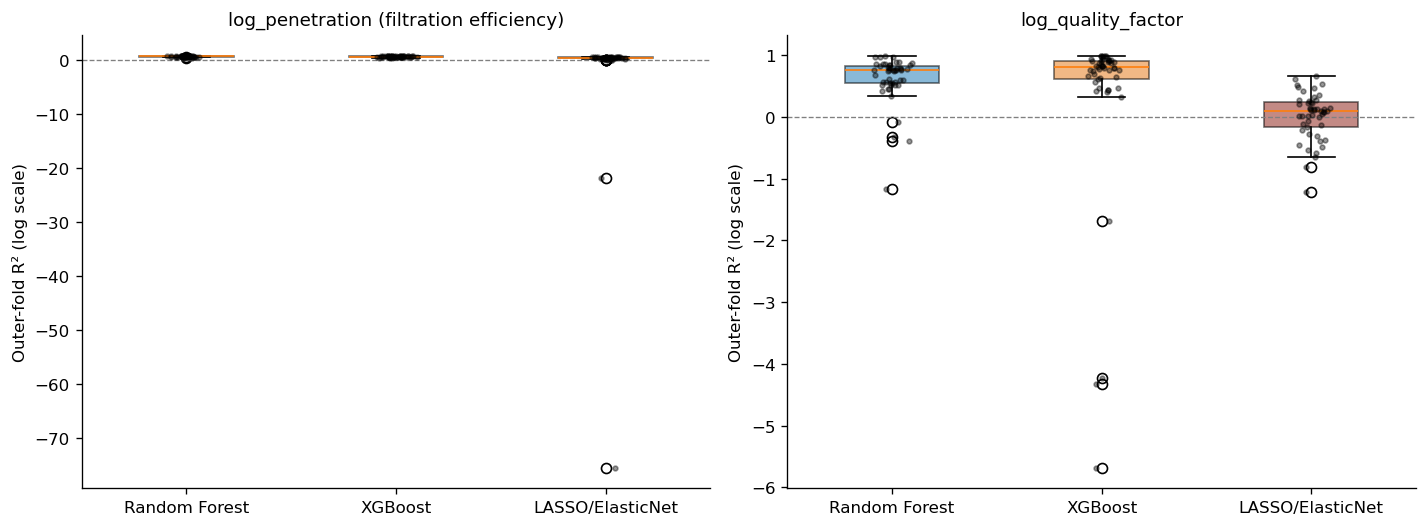

In [13]:
# Box plots of R² across all 50 outer folds per model/target.
# Box = median + IQR; whiskers show the usual box-plot range; individual folds as dots.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, results_list, target_label in [
    (axes[0], [results_rf_eff, results_xgb_eff, results_lasso_eff],
        'log_penetration (filtration efficiency)'),
    (axes[1], [results_rf_qf,  results_xgb_qf,  results_lasso_qf],
        'log_quality_factor'),
]:
    data = [r['fold_r2'] for r in results_list]
    labels = [r['model'] for r in results_list]

    bp = ax.boxplot(data, labels=labels, widths=0.45, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#2980B9', '#E67E22', '#922B21']):
        patch.set_facecolor(color); patch.set_alpha(0.55)

    # Scatter the individual fold R² on top of each box
    for i, scores in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(scores))
        ax.scatter(x, scores, s=8, color='black', alpha=0.4, zorder=5)

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(target_label, fontsize=11)
    ax.set_ylabel('Outer-fold R² (log scale)')

plt.tight_layout()
plt.savefig('nested_cv_model_comparison.png', dpi=600, bbox_inches='tight')
plt.show()


## 4.10: Best hyperparameters — frequency across folds


In [14]:
from collections import Counter

def param_signature(p):
    """Stable string key for a param dict, ignoring boilerplate keys."""
    ignore = {'random_state', 'n_jobs', 'verbosity', 'eval_metric'}
    return str(sorted((k, v) for k, v in p.items() if k not in ignore))


def params_from_signature(sig, sample_dict):
    """Invert param_signature using any dict with the same keys."""
    ignore = {'random_state', 'n_jobs', 'verbosity', 'eval_metric'}
    by_sig = param_signature(sample_dict)
    for p in [sample_dict]:
        if param_signature(p) == sig:
            return {k: v for k, v in p.items() if k not in ignore}
    return None


for target_label, results_list in [
    ('FILTRATION EFFICIENCY', [results_rf_eff, results_xgb_eff, results_lasso_eff]),
    ('QUALITY FACTOR',        [results_rf_qf,  results_xgb_qf,  results_lasso_qf]),
]:
    print(f'\n=== {target_label} ===')
    for r in results_list:
        sigs = [param_signature(p) for p in r['best_params']]
        ctr = Counter(sigs)
        total = len(sigs)
        print(f'\n  {r["model"]} — top 3 configurations (out of {total} folds):')
        for sig, count in ctr.most_common(3):
            for p in r['best_params']:
                if param_signature(p) == sig:
                    clean = {k: v for k, v in p.items()
                             if k not in {'random_state', 'n_jobs',
                                          'verbosity', 'eval_metric'}}
                    print(f'    {count:>3}/{total}  {clean}')
                    break



=== FILTRATION EFFICIENCY ===

  Random Forest — top 3 configurations (out of 50 folds):
     11/50  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
     11/50  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
     10/50  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}

  XGBoost — top 3 configurations (out of 50 folds):
      5/50  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
      4/50  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
      4/50  {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}

  LASSO/ElasticNet — top 3 configurations (out of 50 folds):
     26/50  {'l1_ratio': 0.1, 'max_iter': 10000}
     14/50  {'l1_ratio': 1.0, 'max_iter': 10000}
      6/50  {'l1_ratio': 0.9, 'max_iter': 10000}

=== Q

## 4.11: FINAL MODEL: refit on full dataset

The final deployable model uses the most frequently selected hyperparameter set
across all 50 outer folds. This is more defensible than picking the config from
any single fold, and it converges faster than re-running a separate GridSearchCV
on the full dataset.


In [15]:
def most_common_params(params_list):
    """Return the most frequently occurring parameter dict (ignoring boilerplate keys)."""
    sigs = [param_signature(p) for p in params_list]
    top_sig = Counter(sigs).most_common(1)[0][0]
    for p in params_list:
        if param_signature(p) == top_sig:
            return {k: v for k, v in p.items()
                    if k not in {'n_jobs', 'random_state',
                                 'verbosity', 'eval_metric'}}
    return params_list[0]

# Impute full datasets for refit
imputer_eff = KNNImputer(n_neighbors=5)
X_eff_full  = imputer_eff.fit_transform(X_eff)

imputer_qf  = KNNImputer(n_neighbors=5)
X_qf_full   = imputer_qf.fit_transform(X_qf)

# -------------------------- Final RF for filtration efficiency --------------------------

best_rf_eff_params = most_common_params(results_rf_eff['best_params'])
final_rf_eff = RandomForestRegressor(
    **best_rf_eff_params, random_state=RANDOM_STATE, n_jobs=-1
)
final_rf_eff.fit(X_eff_full, y_eff)
print(f'Final RF (filtration efficiency) — params: {best_rf_eff_params}')

# ------------- Final XGBoost for filtration efficiency ----------------------------------

best_xgb_eff_params = most_common_params(results_xgb_eff['best_params'])
final_xgb_eff = XGBRegressor(
    **best_xgb_eff_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, tree_method='hist',
)
final_xgb_eff.fit(X_eff_full, y_eff)
print(f'Final XGBoost (filtration efficiency) — params: {best_xgb_eff_params}')

# ---------------- Final RF for quality factor -----------------------------------------

best_rf_qf_params = most_common_params(results_rf_qf['best_params'])
final_rf_qf = RandomForestRegressor(
    **best_rf_qf_params, random_state=RANDOM_STATE, n_jobs=-1
)
final_rf_qf.fit(X_qf_full, y_qf)
print(f'Final RF (quality factor) — params: {best_rf_qf_params}')

# ------------------------ Final XGBoost for quality factor -------------------------------

best_xgb_qf_params = most_common_params(results_xgb_qf['best_params'])
final_xgb_qf = XGBRegressor(
    **best_xgb_qf_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, tree_method='hist',
)
final_xgb_qf.fit(X_qf_full, y_qf)
print(f'Final XGBoost (quality factor) — params: {best_xgb_qf_params}')

print('\nAll final models ready for SHAP analysis (Step 5).')


Final RF (filtration efficiency) — params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Final XGBoost (filtration efficiency) — params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Final RF (quality factor) — params: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300}
Final XGBoost (quality factor) — params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}

All final models ready for SHAP analysis (Step 5).


## 4.12: Save final models and results

In [16]:
import pickle

models_to_save = {
    'final_rf_eff':     final_rf_eff,
    'final_xgb_eff':    final_xgb_eff,
    'final_rf_qf':      final_rf_qf,
    'final_xgb_qf':     final_xgb_qf,
    'imputer_eff':      imputer_eff,
    'imputer_qf':       imputer_qf,
    'FEATURES_EFF':     FEATURES_EFF,
    'FEATURES_QF':      FEATURES_QF,
    'X_eff_full':       X_eff_full,
    'X_qf_full':        X_qf_full,
    'y_eff':            y_eff,           # log_penetration
    'y_qf':             y_qf,            # log_quality_factor
    'results_rf_eff':   results_rf_eff,
    'results_xgb_eff':  results_xgb_eff,
    'results_lasso_eff':results_lasso_eff,
    'results_rf_qf':    results_rf_qf,
    'results_xgb_qf':   results_xgb_qf,
    'results_lasso_qf': results_lasso_qf,
}

with open('step4_models.pkl', 'wb') as f:
    pickle.dump(models_to_save, f)

print('Saved: step4_models.pkl')
print('Saved: nested_cv_results.csv')
print('Saved: nested_cv_model_comparison.png')


Saved: step4_models.pkl
Saved: nested_cv_results.csv
Saved: nested_cv_model_comparison.png


## 4.13: Step 4 summary

In [18]:
print('STEP 4 — NESTED CV SUMMARY (RepeatedStratifiedKFold 5×10)')
print('=' * 90)
hdr = f'{"Target":<30} {"Model":<18} {"Mean R²":>9} {"Median":>9} {"IQR":>22} {"95% CI"}'
print(hdr)
print('-' * 90)

for target_label, rf_r, xgb_r, lasso_r in [
    ('log_penetration',    results_rf_eff, results_xgb_eff, results_lasso_eff),
    ('log_quality_factor', results_rf_qf,  results_xgb_qf,  results_lasso_qf),
]:
    for r in [rf_r, xgb_r, lasso_r]:
        ci = r['ci_r2']; iqr = r['iqr_r2']
        iqr_str = f'[{iqr[0]:+.3f}, {iqr[1]:+.3f}]'
        ci_str  = f'[{ci[0]:+.3f}, {ci[1]:+.3f}]'
        print(f'{target_label:<30} {r["model"]:<18} '
              f'{r["mean_r2"]:>+9.4f} {r["median_r2"]:>+9.4f} '
              f'{iqr_str:>22} {ci_str}')
    print()

print('Interpretation:')
print('  - median R² is the preferred headline number (50-fold distribution).')
print('  - IQR width shows fold-to-fold stability; narrow = reliable.')
print('  - The 95% CI is on the mean, not the median — wide CI on mean')
print('    with a high median indicates that a small number of pathological')
print('    folds are dragging the mean down but the model generally works.')
print()
print('Next: Step 5: SHAP feature importance analysis')


STEP 4 — NESTED CV SUMMARY (RepeatedStratifiedKFold 5×10)
Target                         Model                Mean R²    Median                    IQR 95% CI
------------------------------------------------------------------------------------------
log_penetration                Random Forest        +0.6602   +0.6499       [+0.616, +0.707] [+0.638, +0.681]
log_penetration                XGBoost              +0.6370   +0.6319       [+0.583, +0.704] [+0.609, +0.664]
log_penetration                LASSO/ElasticNet     -1.5876   +0.4098       [+0.320, +0.467] [-5.682, +0.393]

log_quality_factor             Random Forest        +0.6193   +0.7531       [+0.543, +0.829] [+0.508, +0.707]
log_quality_factor             XGBoost              +0.3927   +0.8051       [+0.613, +0.902] [-0.016, +0.717]
log_quality_factor             LASSO/ElasticNet     +0.0147   +0.0931       [-0.158, +0.232] [-0.086, +0.119]

Interpretation:
  - median R² is the preferred headline number (50-fold distribution).
  